### Exploratory Data Analysis
Medical Readmission Data

Research Question: What independent variable is most correlated to the readmission of medical patients?

By Stephanie Nguyen

## Null Hypothesis
H<sub>0</sub>: The *Services* variable is independent of readmission.
## Alternative Hypothesis
H<sub>a</sub>: The *Services* variable is dependent on readmission.

In [ ]:
# importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [ ]:
# import medical_raw_data.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\3. EDA in Python\Data\medical_clean.csv")

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(10000, 50)

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [ ]:
# detect null values
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

In [ ]:
# rename columns to provide more information on data provided
df_clean = df.rename(columns={"Item1": "Timely_admission","Item2": "Timely_treatment","Item3": "Timely_visits",
                   "Item4": "Reliability","Item5": "Options","Item6": "Hrs_of_treatment",
                   "Item7": "Courteous_staff","Item8": "Active_listening"})
df_clean.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Timely_admission,Timely_treatment,Timely_visits,Reliability,Options,Hrs_of_treatment,Courteous_staff,Active_listening
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# Find the number of unique values in each variable
for col in df_clean.columns:
    print(col, len(df_clean[col].unique()))

CaseOrder 10000
Customer_id 10000
Interaction 10000
UID 10000
City 6072
State 52
County 1607
Zip 8612
Lat 8588
Lng 8725
Population 5951
Area 3
TimeZone 26
Job 639
Children 11
Age 72
Income 9993
Marital 5
Gender 3
ReAdmis 2
VitD_levels 9976
Doc_visits 9
Full_meals_eaten 8
vitD_supp 6
Soft_drink 2
Initial_admin 3
HighBlood 2
Stroke 2
Complication_risk 3
Overweight 2
Arthritis 2
Diabetes 2
Hyperlipidemia 2
BackPain 2
Anxiety 2
Allergic_rhinitis 2
Reflux_esophagitis 2
Asthma 2
Services 4
Initial_days 9997
TotalCharge 9997
Additional_charges 9418
Timely_admission 8
Timely_treatment 7
Timely_visits 8
Reliability 7
Options 7
Hrs_of_treatment 7
Courteous_staff 7
Active_listening 7


## Remove variables with high cardinality
When dealing with categorical variables, only low cardinality can be accepted. 
Variables with high cardinality (5 levels or more) will be removed from the analysis.

In [ ]:
# List all variables and their data types with 5 levels or less
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        print(col, df_clean[col].dtype)

Area object
Marital object
Gender object
ReAdmis object
Soft_drink object
Initial_admin object
HighBlood object
Stroke object
Complication_risk object
Overweight object
Arthritis object
Diabetes object
Hyperlipidemia object
BackPain object
Anxiety object
Allergic_rhinitis object
Reflux_esophagitis object
Asthma object
Services object


In [ ]:
# Create a list of categorical variables with 5 or less levels
lst = []
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        lst.append(col)

print(lst)

['Area', 'Marital', 'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']


In [ ]:
# Remove ReAdmis variable from list b/c it is the dependent variable
lst.remove('ReAdmis')
print(lst)

['Area', 'Marital', 'Gender', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']


In [ ]:
# count number of independent variables in list
len(lst)

18

# Chi-Square Test
## Goodness of Fit Test vs Test of Independence

Goodness of Fit Test - Measurement of one variable 

Test of Independence - Measurement of two variablesece


In [ ]:
# Set alpha to default value; 95% confident that the results could not happen by random chance
alpha = 0.05

# Create a loop to apply Chi-Square test on all independent variables
lst_var = []
lst_pv = []
for col in lst:
    # Create Chi-Square table
    chi_sq = pd.crosstab(df_clean[col], df_clean['ReAdmis'], margins = False)
    print(chi_sq)

    # Perform the Chi Square test
    stat, p, dof, expected = chi2_contingency(chi_sq)
    print('Chi-Square statistic: ' + str(stat))
    print('P-value: ' + str(p))
    print('Degrees of freedom: ' + str(dof))
    print('Expected Frequency: ' + str(expected))

    # Create a list of all variables and p-values
    lst_var.append(col)
    lst_pv.append(p)

ReAdmis     No   Yes
Area                
Rural     2150  1219
Suburban  2106  1222
Urban     2075  1228
Chi-Square statistic: 0.7133125620168337
P-value: 0.7000130641731285
Degrees of freedom: 2
Expected Frequency: [[2132.9139 1236.0861]
 [2106.9568 1221.0432]
 [2091.1293 1211.8707]]
ReAdmis          No  Yes
Marital                 
Divorced       1283  678
Married        1268  755
Never Married  1243  741
Separated      1259  728
Widowed        1278  767
Chi-Square statistic: 5.085194357694356
P-value: 0.2786671961905379
Degrees of freedom: 4
Expected Frequency: [[1241.5091  719.4909]
 [1280.7613  742.2387]
 [1256.0704  727.9296]
 [1257.9697  729.0303]
 [1294.6895  750.3105]]
ReAdmis      No   Yes
Gender               
Female     3205  1813
Male       2995  1773
Nonbinary   131    83
Chi-Square statistic: 1.5857714961641314
P-value: 0.4525370014241822
Degrees of freedom: 2
Expected Frequency: [[3176.8958 1841.1042]
 [3018.6208 1749.3792]
 [ 135.4834   78.5166]]
ReAdmis       No   Yes

In [ ]:
# Create a dictionary with key = variable and values = p-values
dict_pv = dict(zip(lst_var, lst_pv))
dict_pv

{'Area': 0.7000130641731285,
 'Marital': 0.2786671961905379,
 'Gender': 0.4525370014241822,
 'Soft_drink': 0.4553435616510405,
 'Initial_admin': 0.14298951184306222,
 'HighBlood': 0.8368656684578771,
 'Stroke': 0.9474770077616069,
 'Complication_risk': 0.923567890607327,
 'Overweight': 0.4032948387365496,
 'Arthritis': 0.456479750124403,
 'Diabetes': 0.7775238586920562,
 'Hyperlipidemia': 0.6827258178039075,
 'BackPain': 0.1901293128457823,
 'Anxiety': 0.8271065021209385,
 'Allergic_rhinitis': 0.6571607419560208,
 'Reflux_esophagitis': 0.6022852568865316,
 'Asthma': 0.090951450679407,
 'Services': 0.03075281113212747}

In [ ]:
print('The following independent variable is most correlated to readmission: ' + min(dict_pv, key=dict_pv.get)+ ', P-value: ' + str(min(dict_pv.values())))

The following independent variable is most correlated to readmission: Services, P-value: 0.03075281113212747


In [ ]:
# display contingency table for Services variable
chi_sq_serv = pd.crosstab(df_clean['Services'], df_clean['ReAdmis'], margins = False)
print(chi_sq_serv)

ReAdmis        No   Yes
Services               
Blood Work   3335  1930
CT Scan       737   488
Intravenous  2027  1103
MRI           232   148


In [ ]:
# Perform the Chi-Square test for Services variable
stat, p, dof, expected = chi2_contingency(chi_sq_serv)
print('Chi-Square statistic: ' + str(stat))
print('P-value: ' + str(p))
print('Degrees of freedom: ' + str(dof))
print('Expected Frequency: ' + str(expected))

Chi-Square statistic: 8.892645054628435
P-value: 0.03075281113212747
Degrees of freedom: 3
Expected Frequency: [[3333.2715 1931.7285]
 [ 775.5475  449.4525]
 [1981.603  1148.397 ]
 [ 240.578   139.422 ]]


## Conclusion: The null hypothesis can be rejected.
The p-value is less than 0.05, that is statistically significant.

## Univariate Statistics
Identify the distribution of two continuous variables and two categorical variables using univariate statistics

# Histograms vs Bar Plots: How to determine which plot to use in univariate statistics?

Histograms are used to represent numerical data. Additionally, they allow you to gain insight on distribution shape, detect outliers, and display frequency of data points within each bin.

Bar plots are used to represent categorical data and display frequency of the data.

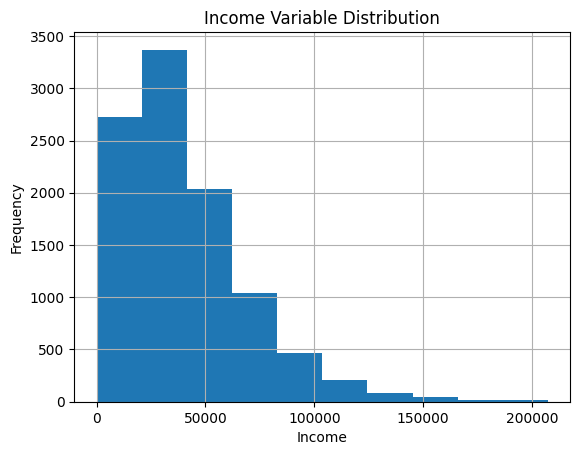

In [ ]:
 # Continuous variable: Income has a positively skewed distribution
df_clean.hist(column = 'Income')
plt.title('Income Variable Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
# plt.savefig('Income Variable Distribution - Histogram.png')
plt.show()

The Income variable has a positively skewed distribution.

In [ ]:
df_clean['Income'].describe()

count     10000.000000
mean      40490.495160
std       28521.153293
min         154.080000
25%       19598.775000
50%       33768.420000
75%       54296.402500
max      207249.100000
Name: Income, dtype: float64

In [ ]:
df_clean['Income'].median()

33768.42

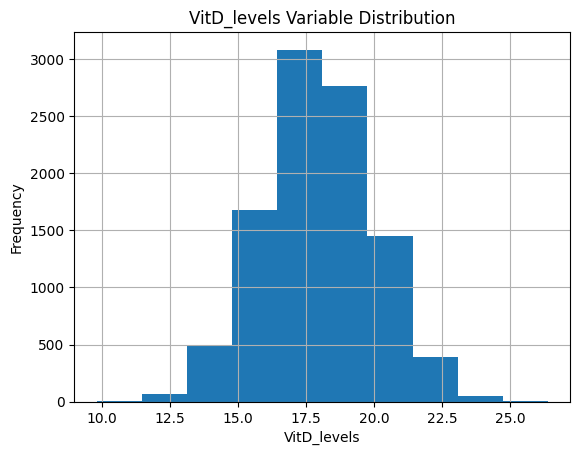

In [ ]:
# Continuous variable: VitD_levels has a narrow range spread distribution 
df_clean.hist(column = 'VitD_levels')
plt.title('VitD_levels Variable Distribution')
plt.xlabel('VitD_levels')
plt.ylabel('Frequency')
# plt.savefig('VitD_levels Variable Distribution - Histogram.png')
plt.show()

The VitD_levels variable has a bimodal distribution.

In [ ]:
df_clean['VitD_levels'].describe()

count    10000.000000
mean        17.964262
std          2.017231
min          9.806483
25%         16.626439
50%         17.951122
75%         19.347963
max         26.394449
Name: VitD_levels, dtype: float64

In [ ]:
df_clean['VitD_levels'].median()

17.951122255

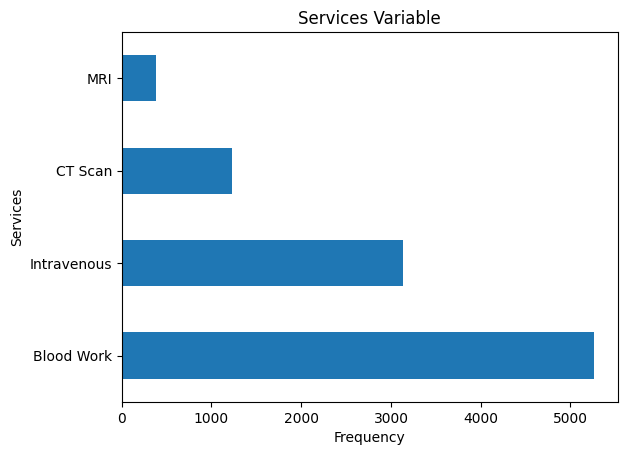

In [ ]:
# Create a horizontal barplot for the categorical variable: Services
df_clean['Services'].value_counts().plot(kind='barh')
plt.title('Services Variable')
plt.xlabel('Frequency')
plt.ylabel('Services')
# plt.savefig('Services Variable - Horizontal Barplot.png',bbox_inches='tight')
plt.show()

In [ ]:
df_clean['Services'].value_counts()

Services
Blood Work     5265
Intravenous    3130
CT Scan        1225
MRI             380
Name: count, dtype: int64

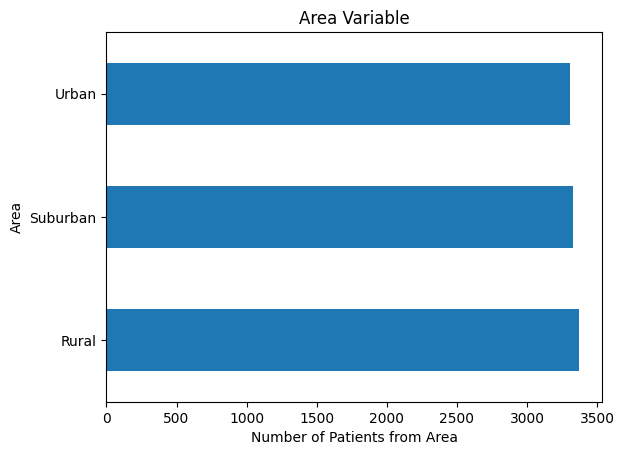

In [ ]:
# Create a horizontal barplot for the categorical variable: Area
df_clean['Area'].value_counts().plot(kind='barh')
plt.title('Area Variable')
plt.xlabel('Number of Patients from Area')
plt.ylabel('Area')
# plt.savefig('Area Variable - Horizontal Barplot.png')
plt.show()

In [ ]:
df_clean['Area'].value_counts()

Area
Rural       3369
Suburban    3328
Urban       3303
Name: count, dtype: int64

## Bivariate Statistics
Identify the distribution of two continuous variables and two categorical variables using bivariate statistics 

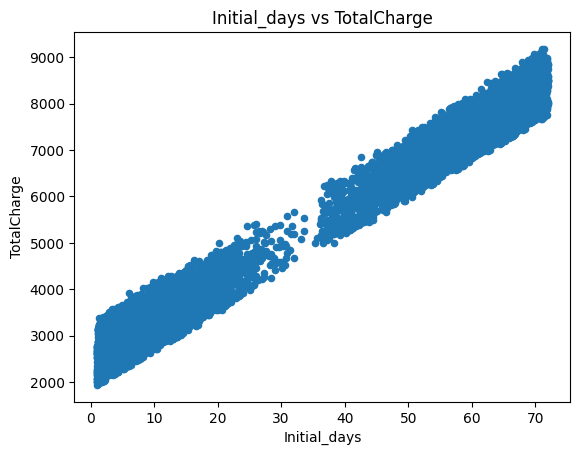

In [ ]:
# scatterplot comparing the two continuous variables Initial_days and TotalCharge
df_clean.plot(x='Initial_days', y='TotalCharge', kind='scatter')
plt.title('Initial_days vs TotalCharge')
# plt.savefig('Initial_days vs TotalCharge - Scatterplot.png')
plt.show()

In [ ]:
# Peason Correlation Analysis on Initial_days and TotalCharge
print(df_clean[['Initial_days','TotalCharge']].corr())

              Initial_days  TotalCharge
Initial_days       1.00000      0.98764
TotalCharge        0.98764      1.00000


The closer the values are to 1, the more correlated they are. As a result, these two categorical values are highly correlated. As the number of initial days increase, so does the total charge. There is a linear, positive relationship.

Text(0.5, 1.0, 'Arthritis vs Area')

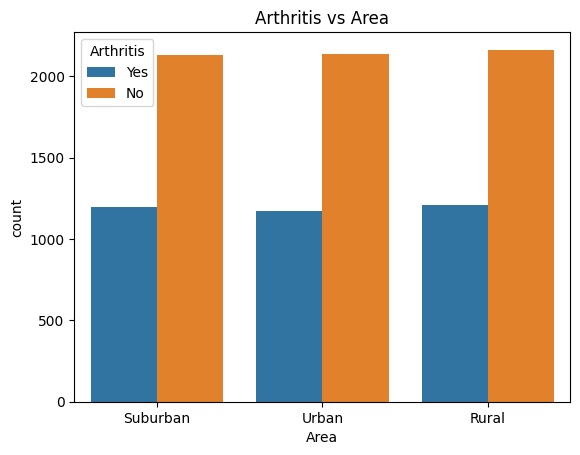

In [ ]:
# countplot comparing the two categorical variables Arthritis and Area
sns.countplot(data=df_clean, x='Area',hue='Arthritis')
plt.title('Arthritis vs Area')
# plt.savefig('Arthritis vs Area - Countplot.png')

In [ ]:
df_clean.groupby('Area')['Arthritis'].value_counts()

Area      Arthritis
Rural     No           2162
          Yes          1207
Suburban  No           2130
          Yes          1198
Urban     No           2134
          Yes          1169
Name: count, dtype: int64

Patients from rural areas had the most cases of arthritis followed by patients from the suburbs.

In [ ]:
# Peason Correlation Analysis on Area and Arthritis
chi_sq = pd.crosstab(df_clean['Area'], df_clean['Arthritis'], margins = False)

# Perform Chi Square test on Area and Arthritis
x2 = chi2_contingency(chi_sq,correction = False)[0]

# Obtain Cramer's V coefficient
n = len(df_clean[['Area','Arthritis']])
minDim = min(df_clean[['Area','Arthritis']].shape)-1
v = np.sqrt((x2/n)/minDim)

# Print Cramer's V correlation coefficient
print(v)

0.005303494482458252


The closer the values are to 1, the more correlated they are. As a result, Area and Arthritis are likely not correlated. 